<a href="https://colab.research.google.com/github/postnicov/ResazurinResorufin/blob/main/Color_wheel_CIE_Lab_a_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIE Lab a–b Chromaticity Diagram

Upload a comma-separated CSV. Header text is ignored: column 1 is always the subset ID, column 2 is always `a`, and column 3 is always `b`.

In [24]:
#@title Cell 1: Check/install packages and import libraries
import importlib
import sys
import subprocess

def ensure_package(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

for package, module in [('numpy', 'numpy'), ('pandas', 'pandas'), ('matplotlib', 'matplotlib')]:
    ensure_package(package, module)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle

print('All required packages are installed and imported.')

All required packages are installed and imported.


In [25]:
#@title Cell 2: Global configuration (font, L, and plot boundaries)
GLOBAL_FONT_SIZE = 12 #@param {type:'integer'}
GLOBAL_FONT_FAMILY = 'Serif' #@param ['Serif', 'Sans-serif', 'Monospace']
GLOBAL_L = 75.0 #@param {type:'number'}
MARKER_SIZE = 12 #@param {type:'integer'}
USE_AUTOMATIC_BOUNDARIES = False #@param {type:'boolean'}
MANUAL_A_MIN = -11.0 #@param {type:'number'}
MANUAL_A_MAX = 11.0 #@param {type:'number'}
MANUAL_B_MIN = -11.0 #@param {type:'number'}
MANUAL_B_MAX = 11.0 #@param {type:'number'}

if MANUAL_A_MIN >= MANUAL_A_MAX or MANUAL_B_MIN >= MANUAL_B_MAX:
    raise ValueError('Each manual lower boundary must be smaller than its upper boundary.')

plt.rcParams.update({
    'font.size': GLOBAL_FONT_SIZE,
    'font.family': GLOBAL_FONT_FAMILY,
    'figure.figsize': (6, 6),
    'axes.grid': True,
})

mode = 'automatic' if USE_AUTOMATIC_BOUNDARIES else 'manual'
print(f'Configuration applied: L = {GLOBAL_L}; boundaries = {mode}.')

Configuration applied: L = 75.0; boundaries = manual.


In [26]:
#@title Cell 3: Upload comma-separated CSV (columns 1–3 = ID, a, b)
from google.colab import files

print('Upload a comma-separated CSV. Header text is ignored; columns 1, 2, and 3 are always read as ID, a, and b.')
uploaded = files.upload()
if not uploaded:
    raise ValueError('No CSV file was uploaded.')

csv_filename = next(iter(uploaded))
raw_df = pd.read_csv(csv_filename, sep=',', header=0)

if raw_df.shape[1] < 3:
    raise ValueError('The CSV must contain at least three comma-separated columns.')

# Ignore all CSV header text. Positional assignment is deliberate.
df = raw_df.iloc[:, :3].copy()
df.columns = ['ID', 'a', 'b']
df['ID'] = df['ID'].astype(str).str.strip()
df['a'] = pd.to_numeric(df['a'], errors='raise')
df['b'] = pd.to_numeric(df['b'], errors='raise')

def natural_sort_key(value):
    import re
    return [int(part) if part.isdigit() else part.casefold() for part in re.split(r'(\d+)', str(value))]

subset_ids = sorted(df['ID'].unique(), key=natural_sort_key)
df['_subset_order'] = pd.Categorical(df['ID'], categories=subset_ids, ordered=True)
df = (df.sort_values(['_subset_order', 'a', 'b'], kind='stable')
        .drop(columns='_subset_order')
        .reset_index(drop=True))

print(f'Using file: {csv_filename}')
print(f'Unique subset IDs ({len(subset_ids)}): {subset_ids}')
display(df.head())

Upload a comma-separated CSV. Header text is ignored; columns 1, 2, and 3 are always read as ID, a, and b.


Saving Resazurin_Resorufin_pH_ab.csv to Resazurin_Resorufin_pH_ab (5).csv
Using file: Resazurin_Resorufin_pH_ab (5).csv
Unique subset IDs (17): ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0', '5.5', '6.0', '6.5', '7.0', '7.5', '8.0', '8.5', '9.0']


,ID,a,b
0,1.0,1.996,2.351
1,1.0,2.183,2.227
2,1.0,2.361,2.113
3,1.0,2.531,2.005
4,1.0,2.695,1.904


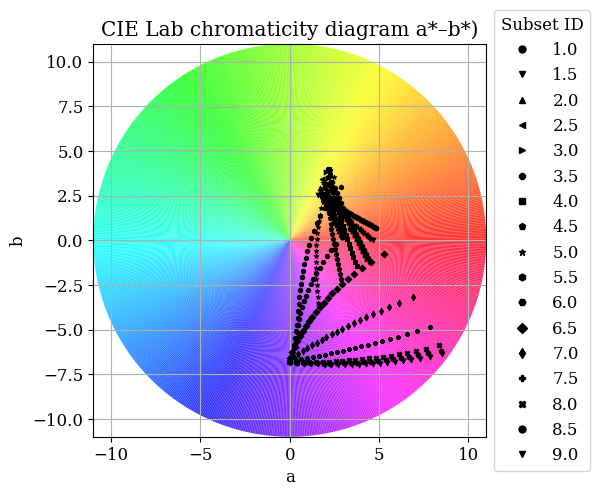

In [27]:
#@title Cell 4: Plot CIE Lab a–b chromaticity diagram
a_values = df['a'].to_numpy()
b_values = df['b'].to_numpy()

if USE_AUTOMATIC_BOUNDARIES:
    max_extent = max(np.max(np.abs(a_values)), np.max(np.abs(b_values)), 1.0)
    plot_radius = 1.10 * max_extent
    a_min, a_max = -plot_radius, plot_radius
    b_min, b_max = -plot_radius, plot_radius
else:
    a_min, a_max = MANUAL_A_MIN, MANUAL_A_MAX
    b_min, b_max = MANUAL_B_MIN, MANUAL_B_MAX
    plot_radius = max(abs(a_min), abs(a_max), abs(b_min), abs(b_max))

theta = np.linspace(0, 2 * np.pi, 720)
circle_a = plot_radius * np.cos(theta)
circle_b = plot_radius * np.sin(theta)
circle_colors = plt.get_cmap('hsv')(theta[:-1] / (2 * np.pi))
segments = [
    [(0, 0), (circle_a[i], circle_b[i]), (circle_a[i + 1], circle_b[i + 1])]
    for i in range(len(theta) - 1)
]

fig, ax = plt.subplots()
ax.add_collection(PolyCollection(
    segments, facecolors=circle_colors, edgecolors='none', alpha=0.80, zorder=0
))
ax.set_aspect('equal', adjustable='box')

excluded_markers = {'.', ',', ' ', 'None', 'none', None}
filled_markers = [marker for marker in MarkerStyle.filled_markers if marker not in excluded_markers]
marker_map = {subset_id: filled_markers[i % len(filled_markers)] for i, subset_id in enumerate(subset_ids)}

legend_handles = []
for subset_id in subset_ids:
    group = df.loc[df['ID'] == subset_id]
    marker = marker_map[subset_id]
    ax.scatter(
        group['a'], group['b'], s=MARKER_SIZE, marker=marker,
        facecolors='black', edgecolors='black', linewidths=0.7, zorder=3
    )
    legend_handles.append(Line2D(
        [0], [0], marker=marker, color='black', markerfacecolor='black',
        markeredgecolor='black', linestyle='None',
        markersize=max(np.sqrt(MARKER_SIZE), 5), label=subset_id
    ))

ax.axhline(0, color='gray', linewidth=0.8, zorder=1)
ax.axvline(0, color='gray', linewidth=0.8, zorder=1)
ax.set_xlim(a_min, a_max)
ax.set_ylim(b_min, b_max)
ax.set_xlabel('a')
ax.set_ylabel('b')
boundary_label = (
    'automatic boundaries' if USE_AUTOMATIC_BOUNDARIES
    else f'manual boundaries: a=({a_min:g}, {a_max:g}), b=({b_min:g}, {b_max:g})'
)
ax.set_title(f'CIE Lab chromaticity diagram a*–b*)')

ax.legend(
    handles=legend_handles, title='Subset ID', loc='center left',
    bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, frameon=True
)
fig.subplots_adjust(right=0.78)
plt.show()